# Causal signal replay on real Polymarket books

Synthetic data proves the plumbing works. It cannot tell you whether a
strategy works, because what you find in it is the structure the generator
put there.

Real books are the test, and they punish design errors a generator forgives.
A feature computed from the bar it trades in, a resolution label that leaked
into a signal, a fill assumed at a price the book never showed: each of those
turns a losing rule into a winning backtest.

This recipe builds a deliberately modest microstructure strategy on the
bounded [Kaggle Polymarket sample](https://www.kaggle.com/datasets/marvingozo/polymarket-tick-level-orderbook-dataset).
The professional lesson is the experimental design:

- features become observable only after their minute closes;
- the eventual resolution label is excluded;
- orders meet real recorded books, not feature-bar prices;
- fees, latency, and slippage are sensitivity dimensions;
- every run is pinned and queryable on its own fork.

## Terms used here

| term             | meaning |
| ---------------- | --- |
| replay           | running recorded market data back through the engine in its original order |
| causal feature   | one computed only from data observable at its own timestamp |
| observability    | when a value actually became knowable, which is not when the event happened |
| resolution label | the eventual outcome, which the strategy must never see |
| imbalance        | bid size relative to ask size at the top of book |
| z-score          | how many standard deviations a value sits from its rolling mean |
| run fork         | an isolated branch of the database a run writes its results into |

New to any of these? [GLOSSARY.md](../../GLOSSARY.md) defines them at more
length, along with every other term the cookbook uses.

In [1]:
import datetime as dt
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import h5i_db
from h5i_db import backtest
import cookbook_utils as cu

CACHE = Path("data/cache/kaggle-polymarket")
sample = cu.load_kaggle_sample(CACHE, depth_levels=10)
print(sample.question)
print(pd.Series(sample.audit, name="value").to_frame())

Will global temperature increase by between 1.10ºC and 1.14ºC in February 2026?
                                                                       value
dataset                    marvingozo/polymarket-tick-level-orderbook-dat...
license                                                         CC BY-NC 4.0
sample_date                                                       2026-03-09
source_snapshot_rows                                                     227
source_feature_rows                                                     1390
source_trade_rows                                                        198
canonical_book_rows                                                     4540
canonical_trade_rows                                                     198
depth_levels                                                              10
trade_aggressor_known                                                  False
clock_adjustments                                                        

## Build a causal feature

`depth_imbalance` at minute *t* is stamped at *t + 1 minute* by the loader.
Its baseline uses only the preceding 120 observations: both rolling moments
are shifted before the current z-score is calculated. The first absolute
two-sigma event opens one position; a fixed two-hour horizon closes it.

This is an execution tutorial, not a mined trading rule. One market and one
day are far too little evidence for model selection.

In [2]:
features = sample.features.to_pandas()
depth = features["depth_imbalance"]
features["history_mean"] = depth.rolling(120, min_periods=60).mean().shift(1)
features["history_std"] = depth.rolling(120, min_periods=60).std().shift(1)
features["depth_z"] = (
    (depth - features["history_mean"]) / features["history_std"].replace(0, np.nan)
)

book_times = sample.book_deltas.column("ts_init")
book_start = pd.Timestamp(book_times[0].as_py())
book_end = pd.Timestamp(book_times[-1].as_py())
eligible = features[
    features["ts_init"].between(
        book_start, book_end - pd.Timedelta(hours=2), inclusive="both"
    )
    & features["depth_z"].abs().ge(2.0)
]
assert not eligible.empty
entry = eligible.iloc[0]
exit_time = entry["ts_init"] + pd.Timedelta(hours=2)
direction = "buy" if entry["depth_z"] > 0 else "sell"
close_direction = "sell" if direction == "buy" else "buy"
print(
    f"{direction=} at {entry['ts_init']} z={entry['depth_z']:.2f}; "
    f"close at {exit_time}"
)

direction='buy' at 2026-03-09 06:51:00 z=2.13; close at 2026-03-09 08:51:00


Signals are timestamped intent. They contain no execution price. That
prevents the common mistake of filling at the same bar close that generated
the signal.

In [3]:
quantity = 20.0
signals = backtest.signal_table(
    [
        {
            "ts": entry["ts_init"].to_pydatetime(),
            "instrument_id": sample.market_id,
            "side": direction,
            "quantity": quantity,
            "tag": "depth-z-entry",
        },
        {
            "ts": exit_time.to_pydatetime(),
            "instrument_id": sample.market_id,
            "side": close_direction,
            "quantity": quantity,
            "tag": "time-exit",
        },
    ]
)
signals.to_pandas()

,ts,instrument_id,outcome,side,quantity,kind,limit_price,time_in_force,tag,reduce_only
0,2026-03-09 06:51:00,0x7d4e693277c1d7990a5227146ee70f56750c73be6f9d...,0,buy,20.0,market,NaN,NaN,depth-z-entry,False
1,2026-03-09 08:51:00,0x7d4e693277c1d7990a5227146ee70f56750c73be6f9d...,0,sell,20.0,market,NaN,NaN,time-exit,False


## Pin data before running

In [4]:
db = h5i_db.Database(cu.fresh_db("05_kaggle_polymarket_replay"), create=True)
for name, table in {
    "instruments": sample.instruments,
    "book_deltas": sample.book_deltas,
    "trades": sample.trades,
    "features_1m": sample.features,
}.items():
    db.create_table(name, table.schema, time_column="ts_init")
    db.append(name, table, note="bounded CC BY-NC Kaggle Polymarket sample")
db.snapshot(
    "approved-kaggle-cut",
    tables=["instruments", "book_deltas", "trades", "features_1m"],
    note="Real snapshot replay inputs; resolution label excluded",
)
backtest.create_signal_table(db)
db.append("signals", signals, note="causal depth-imbalance experiment")

{'table': 'signals',
 'sequence': 1,
 'op': 'append',
 'rows_total': 2,
 'segments_total': 1,
 'segments_added': 1,
 'segments_deduped': 0,
 'committed_at_ns': 1785448970776699109}

## Treat execution assumptions as model risk

The snapshot feed cannot support exact queue depletion, so this experiment
uses market orders and does not enable queue-position fills. We vary the
curved Polymarket fee rate, latency, and adverse slippage. The baseline is
intentionally not presented alone.

In [5]:
scenarios = {
    "frictionless": {
        "fee_rate": 0.0,
        "latency_nanos": 0,
        "slippage_ticks": 0,
    },
    "base": {
        "fee_rate": 0.02,
        "latency_nanos": 50_000_000,
        "slippage_ticks": 0,
    },
    "stressed": {
        "fee_rate": 0.035,
        "latency_nanos": 250_000_000,
        "slippage_ticks": 2,
    },
}
reports = {}
inspections = {}
for name, assumptions in scenarios.items():
    config = backtest.BacktestConfig(
        run_id=f"kaggle-{name}",
        portfolio=backtest.PortfolioConfig(starting_cash=10_000.0),
        data=backtest.DataConfig(
            signals="signals",
            snapshot="approved-kaggle-cut",
            minimum_coverage=0.75,
        ),
        execution=backtest.ExecutionConfig(
            fee_kind="prediction_market",
            fee_rate=assumptions["fee_rate"],
            latency_nanos=assumptions["latency_nanos"],
            slippage_ticks=assumptions["slippage_ticks"],
        ),
        risk=backtest.RiskConfig(
            max_order_quantity=quantity,
            max_abs_position=quantity,
            max_open_orders=1,
        ),
        output=backtest.OutputConfig(
            equity_interval_nanos=60_000_000_000,
        ),
        metadata={
            "dataset": cu.KAGGLE_POLYMARKET_DATASET,
            "scenario": name,
            "signal": "causal depth imbalance",
        },
    )
    inspections[name] = backtest.inspect(db, config)
    inspections[name].raise_for_errors()
    reports[name] = backtest.execute(db, config)

summary = pd.DataFrame(reports).T[
    ["fills", "commissions", "realized_pnl", "final_cash", "digest", "fork"]
]
summary

,fills,commissions,realized_pnl,final_cash,digest,fork
frictionless,3,0.0,-0.46104,9999.53896,0d433c0e190b98dfb7ebb5f472135ece67380f05444d9f...,bt-kaggle-frictionless
base,3,0.022064,-0.483104,9999.516896,bca780e0f1544505ff362b9962f93e9fcdf6c646d634dc...,bt-kaggle-base
stressed,3,0.038605,-0.507645,9999.492355,d40a2d70586585890677803b9cd7f9267e51c6ea5a53b2...,bt-kaggle-stressed


Preflight classifies this source as snapshot L2 rather than tick-delta L2.
That fidelity statement is part of the result and prevents the notebook from
quietly making queue-position claims the source cannot support.

In [6]:
{
    name: {
        "fidelity": inspection.fidelity.value,
        "warnings": [issue.message for issue in inspection.warnings],
    }
    for name, inspection in inspections.items()
}

{'frictionless': {'fidelity': 'snapshot_l2',
  'warnings': ['periodic snapshots cannot reconstruct queue transitions between events']},
 'base': {'fidelity': 'snapshot_l2',
  'warnings': ['periodic snapshots cannot reconstruct queue transitions between events']},
 'stressed': {'fidelity': 'snapshot_l2',
  'warnings': ['periodic snapshots cannot reconstruct queue transitions between events']}}

A valid comparison fully executes the same two tagged orders in every
scenario. One order may generate multiple fills when it walks book levels;
counting fills as trades would be a subtle analysis error. The digest changes
because execution configuration is part of run identity.

In [7]:
assert summary["fills"].ge(2).all()
assert summary["digest"].nunique() == len(summary)

fill_frames = []
for scenario, report in reports.items():
    run_db = db.fork(report["fork"])
    scenario_fills = run_db.read("bt_fills").to_pandas()
    filled_by_tag = scenario_fills.groupby("tag")["quantity"].sum()
    assert set(filled_by_tag.index) == {"depth-z-entry", "time-exit"}
    assert filled_by_tag.eq(quantity).all()
    scenario_fills["scenario"] = scenario
    fill_frames.append(scenario_fills)
    run_db.close()

# verify() reruns the config into a scratch fork and tears it down afterwards,
# so read the run's own fork before calling it.
assert reports["base"].verify()["verified"]

fills = pd.concat(fill_frames, ignore_index=True)
fills[["scenario", "ts", "side", "price", "quantity", "commission", "tag"]]

,scenario,ts,side,price,quantity,commission,tag
0,frictionless,2026-03-09 07:16:15.335,buy,0.0400,18.96,0.000000,depth-z-entry
1,frictionless,2026-03-09 07:16:15.335,buy,0.0410,1.04,0.000000,depth-z-entry
2,frictionless,2026-03-09 08:52:29.671,sell,0.0170,20.00,0.000000,time-exit
3,base,2026-03-09 07:16:19.000,buy,0.0400,18.96,0.014561,depth-z-entry
4,base,2026-03-09 07:16:19.000,buy,0.0410,1.04,0.000818,depth-z-entry
5,base,2026-03-09 08:52:33.000,sell,0.0170,20.00,0.006684,time-exit
6,stressed,2026-03-09 07:16:19.000,buy,0.0402,18.96,0.025604,depth-z-entry
7,stressed,2026-03-09 07:16:19.000,buy,0.0412,1.04,0.001438,depth-z-entry
8,stressed,2026-03-09 08:52:33.000,sell,0.0168,20.00,0.011562,time-exit


Plot equity from the most conservative scenario. Output frequency is one
minute even though the engine consumes every retained book event.

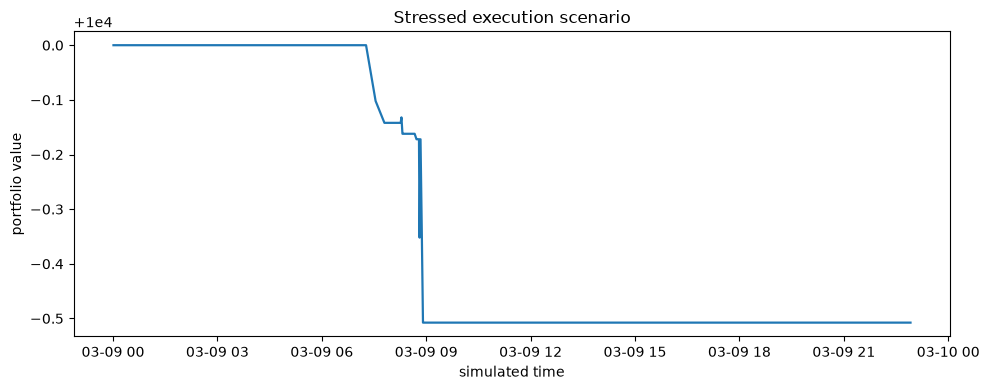

In [8]:
stressed_db = db.fork(reports["stressed"]["fork"])
equity = stressed_db.read("bt_equity").to_pandas()
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(equity["ts"], equity["equity"], linewidth=1.6)
ax.set(
    title="Stressed execution scenario",
    xlabel="simulated time",
    ylabel="portfolio value",
)
fig.tight_layout()

## Production checklist

- Repeat across many markets and non-overlapping dates; this single trade is
  a pipeline test, not statistical evidence.
- Pin the external file hashes alongside the h5i-db snapshot.
- Calibrate fee rates to the venue and market date.
- Use tick deltas, not periodic snapshots, before enabling queue-position
  claims.
- Report rejected orders, coverage, turnover, and sensitivity—not only P&L.
- Respect the source dataset's non-commercial license.

In [9]:
stressed_db.close()
db.close()